## 0 · Setup

In [ ]:
!pip install -q transformers datasets pillow pandas numpy matplotlib torch nltk groq jiwer scikit-learn
import nltk; nltk.download("punkt", quiet=True); nltk.download("punkt_tab", quiet=True)
print("Done")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 117.8 MB/s eta 0:00:00
Done


In [ ]:
import re, os, json, warnings; warnings.filterwarnings("ignore")
from datetime import datetime
from dataclasses import dataclass, asdict
from typing import Optional, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import (TrOCRProcessor, VisionEncoderDecoderModel,
                          BertTokenizer, BertModel,
                          get_linear_schedule_with_warmup,
                          get_cosine_schedule_with_warmup)
from datasets import load_dataset
from sklearn.metrics import cohen_kappa_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from jiwer import cer as compute_cer, wer as compute_wer
from PIL import Image
from groq import Groq

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {DEVICE}")

Device : cuda


---
## Step 1 · Answer Script + Rubric
###  80/20 split of train.csv → ~850 validation samples

Total rows  : 4274
Train split : 3419  (CC-BERT + CSRF training)
Val split   : 855    (threshold tuning + evaluation)
Score range : 0 – 5


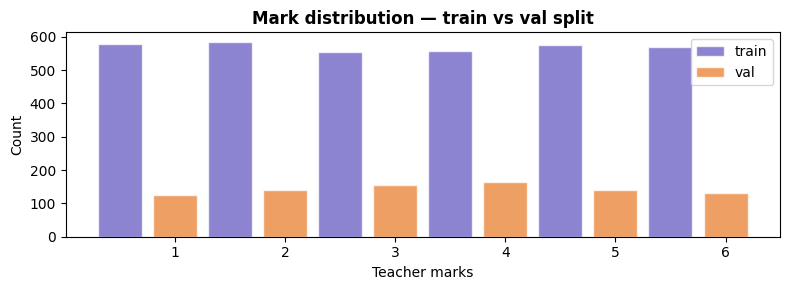

In [ ]:
@dataclass
class RubricEntry:
    question:       str
    model_answer:   str
    total_marks:    int
    student_answer: Optional[str] = None
    teacher_marks:  Optional[int] = None

def build_rubric(df: pd.DataFrame) -> List[RubricEntry]:
    return [RubricEntry(str(r["questions"]), str(r["model_answer"]), int(r["total_marks"]),
                        str(r["student_answer"]), int(r["teacher_marks"]))
            for _, r in df.iterrows()]

# Load full train.csv and split 80/20
full_df   = pd.read_csv("train.csv")
test_df   = pd.read_csv("test.csv")   # kept aside — not used for eval

train_df, val_df = train_test_split(full_df, test_size=0.2,
                                     random_state=42, shuffle=True)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)

rubric_train = build_rubric(train_df)
rubric_val   = build_rubric(val_df)

print(f"Total rows  : {len(full_df)}")
print(f"Train split : {len(train_df)}  (CC-BERT + CSRF training)")
print(f"Val split   : {len(val_df)}    (threshold tuning + evaluation)")
print(f"Score range : {full_df['teacher_marks'].min()} – {full_df['teacher_marks'].max()}")

# Quick EDA
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(train_df["teacher_marks"], bins=range(0, int(full_df["total_marks"].max())+2),
        alpha=0.7, color="#5B4FBE", edgecolor="white", label="train", rwidth=0.4)
ax.hist(val_df["teacher_marks"],   bins=range(0, int(full_df["total_marks"].max())+2),
        alpha=0.7, color="#E87722", edgecolor="white", label="val",   rwidth=0.4,
        align="right")
ax.set_title("Mark distribution — train vs val split", fontweight="bold")
ax.set_xlabel("Teacher marks"); ax.set_ylabel("Count"); ax.legend()
plt.tight_layout(); plt.show()

---
## Step 3 · CC-BERT — Semantic Grading Embedding  ★
###

In [ ]:
BERT_MODEL = "bert-base-uncased"; MAX_LEN = 128
tokenizer  = BertTokenizer.from_pretrained(BERT_MODEL)

class CCBERT(nn.Module):
    def __init__(self, embed_dim: int = 256):
        super().__init__()
        self.bert = BertModel.from_pretrained(BERT_MODEL)
        h = self.bert.config.hidden_size
        self.proj = nn.Sequential(
            nn.Linear(h, embed_dim), nn.LayerNorm(embed_dim),
            nn.ReLU(), nn.Linear(embed_dim, embed_dim)
        )
    def encode(self, ids, mask):
        out  = self.bert(input_ids=ids, attention_mask=mask)
        m    = mask.unsqueeze(-1).float()
        emb  = (out.last_hidden_state * m).sum(1) / m.sum(1).clamp(min=1e-9)
        return F.normalize(self.proj(emb), dim=-1)
    def forward(self, b):
        return self.encode(b["ids_s"], b["mask_s"]), self.encode(b["ids_m"], b["mask_m"])

cc_bert = CCBERT().to(DEVICE)
print(f"CC-BERT  |  params: {sum(p.numel() for p in cc_bert.parameters())/1e6:.1f}M")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


CC-BERT  |  params: 109.7M


In [ ]:
class PairDataset(Dataset):
    def __init__(self, pairs): self.pairs = pairs
    def __len__(self): return len(self.pairs)
    def __getitem__(self, i):
        p  = self.pairs[i]
        es = tokenizer(p["s"], truncation=True, max_length=MAX_LEN,
                       padding="max_length", return_tensors="pt")
        em = tokenizer(p["m"], truncation=True, max_length=MAX_LEN,
                       padding="max_length", return_tensors="pt")
        return {"ids_s":  es["input_ids"].squeeze(0),
                "mask_s": es["attention_mask"].squeeze(0),
                "ids_m":  em["input_ids"].squeeze(0),
                "mask_m": em["attention_mask"].squeeze(0),
                "score":  torch.tensor(p["score"], dtype=torch.float)}


# Build pairs from TRAIN split only (not val)
all_pairs = [
    {"s": str(r["student_answer"]), "m": str(r["model_answer"]),
     "score": float(r["teacher_marks"]) / float(r["total_marks"])}
    for _, r in train_df.iterrows()
]

# Curriculum: sort easy (extreme scores) first — all data used from epoch 1
# Curriculum schedule: ep1=25%, ep2=50%, ep3=75%, ep4-10=100%
pairs_sorted = sorted(all_pairs, key=lambda p: abs(p["score"] - 0.5), reverse=True)
n            = len(pairs_sorted)

def get_curriculum_subset(epoch, total_epochs=10):
    """Ramp from 25% to 100% over first 4 epochs, then full dataset."""
    if epoch == 0: return pairs_sorted[:n // 4]
    if epoch == 1: return pairs_sorted[:n // 2]
    if epoch == 2: return pairs_sorted[:3 * n // 4]
    return pairs_sorted   # epochs 3–9: full dataset

print(f"Training pairs : {n}  (from {len(train_df)}-row train split)")
print("Curriculum     : 25% → 50% → 75% → 100% (epochs 1–4, then full)")

Training pairs : 3419  (from 3419-row train split)
Curriculum     : 25% → 50% → 75% → 100% (epochs 1–4, then full)


Epoch 01/10  loss=0.14929  pairs=  854  lr=5.93e-06
Epoch 02/10  loss=0.09954  pairs= 1709  lr=1.78e-05
Epoch 03/10  loss=0.06430  pairs= 2564  lr=1.96e-05
Epoch 04/10  loss=0.03439  pairs= 3419  lr=1.78e-05
Epoch 05/10  loss=0.02025  pairs= 3419  lr=1.46e-05
Epoch 06/10  loss=0.01257  pairs= 3419  lr=1.07e-05
Epoch 07/10  loss=0.00928  pairs= 3419  lr=6.66e-06
Epoch 08/10  loss=0.00753  pairs= 3419  lr=3.18e-06
Epoch 09/10  loss=0.00697  pairs= 3419  lr=8.29e-07
Epoch 10/10  loss=0.00687  pairs= 3419  lr=0.00e+00

CC-BERT training complete  (total steps: 911)


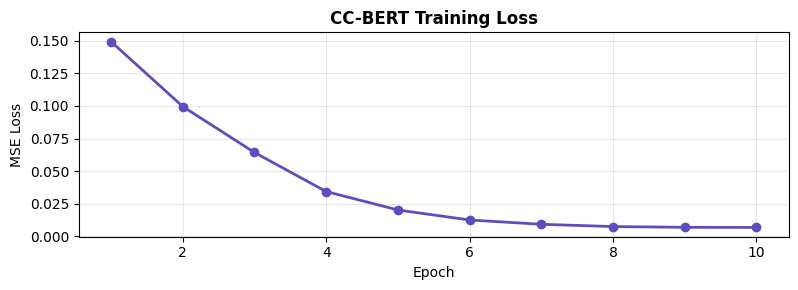

In [13]:
# ── Training loop — Fix 4: 10 epochs + cosine LR decay ─────────────────────

EPOCHS     = 10
BATCH_SIZE = 32
LR         = 2e-5

optimizer  = torch.optim.AdamW(cc_bert.parameters(), lr=LR, weight_decay=0.01)
cc_bert.train()

# Pre-compute total steps for cosine schedule
total_steps  = sum(len(DataLoader(PairDataset(get_curriculum_subset(ep)), batch_size=BATCH_SIZE))
                   for ep in range(EPOCHS))
warmup_steps = total_steps // 10
scheduler    = get_cosine_schedule_with_warmup(optimizer, warmup_steps, total_steps)

history = []
step_count = 0

for epoch in range(EPOCHS):
    subset     = get_curriculum_subset(epoch)
    dataloader = DataLoader(PairDataset(subset), batch_size=BATCH_SIZE, shuffle=True)
    ep_loss    = 0

    for b in dataloader:
        b = {k: v.to(DEVICE) for k, v in b.items()}
        es, em = cc_bert(b)
        loss   = F.mse_loss(F.cosine_similarity(es, em), b["score"])
        optimizer.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(cc_bert.parameters(), 1.0)
        optimizer.step(); scheduler.step()
        ep_loss += loss.item(); step_count += 1

    avg = ep_loss / len(dataloader)
    history.append(avg)
    lr_now = scheduler.get_last_lr()[0]
    print(f"Epoch {epoch+1:02d}/{EPOCHS}  loss={avg:.5f}  "
          f"pairs={len(subset):5d}  lr={lr_now:.2e}")

cc_bert.eval()
print(f"\nCC-BERT training complete  (total steps: {step_count})")

plt.figure(figsize=(8, 3))
plt.plot(range(1, EPOCHS+1), history, marker="o", color="#5B4FBE", lw=2)
plt.title("CC-BERT Training Loss", fontweight="bold")
plt.xlabel("Epoch"); plt.ylabel("MSE Loss"); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [14]:
def embed(texts: List[str]) -> np.ndarray:
    enc = tokenizer(texts, truncation=True, max_length=MAX_LEN,
                    padding="max_length", return_tensors="pt")
    enc = {k: v.to(DEVICE) for k, v in enc.items()}
    with torch.no_grad():
        return cc_bert.encode(enc["input_ids"], enc["attention_mask"]).cpu().numpy()

# Evaluate CC-BERT on val split
s_embs = embed(val_df["student_answer"].tolist())
m_embs = embed(val_df["model_answer"].tolist())
cos    = (s_embs * m_embs).sum(axis=1)
norm_s = (val_df["teacher_marks"] / val_df["total_marks"]).values

ccbert_corr = float(np.corrcoef(cos, norm_s)[0,1])
ccbert_mae  = float(np.abs(cos - norm_s).mean())
print(f"CC-BERT val Pearson r : {ccbert_corr:.4f}  [target > 0.60]")
print(f"CC-BERT val MAE       : {ccbert_mae:.4f}  [target < 0.15]")

CC-BERT val Pearson r : 0.8085  [target > 0.60]
CC-BERT val MAE       : 0.1357  [target < 0.15]


---
## Step 4 · Rubric Decomposer

In [15]:
@dataclass
class Criterion:
    text: str; criterion_emb: np.ndarray; best_match_sent: str = ""
    match_similarity: float = 0.0; coverage: float = 0.0; marks_awarded: float = 0.0

@dataclass
class DecomposedRubric:
    question: str; total_marks: int; criteria: List[Criterion]
    student_sentences: List[str]; predicted_score: float = 0.0
    coverage_threshold: float = 0.55

def split_criteria(text: str) -> List[str]:
    try:    sents = nltk.sent_tokenize(text)
    except: sents = re.split(r"[.;]", text)
    out = [s.strip().rstrip(".") for s in sents if len(s.split()) >= 5]
    return out or [text.strip()]

def split_sentences(text: str) -> List[str]:
    try:    sents = nltk.sent_tokenize(text)
    except: sents = re.split(r"[.;]", text)
    return [s.strip() for s in sents if len(s.strip()) > 3]

def decompose_rubric(entry: RubricEntry, student_text: str,
                      threshold: float = 0.55) -> DecomposedRubric:
    raw   = split_criteria(entry.model_answer)
    sents = split_sentences(student_text) or [student_text]
    ce    = embed(raw); se = embed(sents)
    mpc   = entry.total_marks / max(1, len(raw))
    clist = []
    for i, txt in enumerate(raw):
        sims = (ce[i] * se).sum(axis=1)
        bi   = int(np.argmax(sims)); bs = float(sims[bi])
        cov  = min(1.0, max(0.0, bs / threshold))
        clist.append(Criterion(txt, ce[i], sents[bi],
                               round(bs,4), round(cov,4), round(cov*mpc,3)))
    pred = min(entry.total_marks, sum(c.marks_awarded for c in clist))
    return DecomposedRubric(entry.question, entry.total_marks,
                            clist, sents, round(pred,3), threshold)

print("Rubric Decomposer defined")

Rubric Decomposer defined


---
## Step 5 · Threshold Tuning  
### Fix 3: grid-search coverage threshold on val split → pick best QWK

In [16]:
print("Grid-searching coverage threshold on val split …")
print("(this runs decompose_rubric for each threshold — takes a few minutes)\n")

THRESHOLDS   = np.arange(0.30, 0.81, 0.05)
th_results   = []
max_mark     = int(full_df["total_marks"].max())

for th in THRESHOLDS:
    preds, truths = [], []
    for entry in rubric_val:
        dr = decompose_rubric(entry, entry.student_answer, threshold=th)
        preds.append(round(dr.predicted_score))
        truths.append(entry.teacher_marks)

    p_int = np.clip(np.array(preds),  0, max_mark)
    t_int = np.clip(np.array(truths), 0, max_mark)
    qwk   = cohen_kappa_score(t_int, p_int, weights="quadratic")
    mae   = float(np.abs(p_int - t_int).mean())
    th_results.append({"threshold": round(th,2), "qwk": round(qwk,4), "mae": round(mae,4)})
    print(f"  threshold={th:.2f}  QWK={qwk:.4f}  MAE={mae:.4f}")

th_df = pd.DataFrame(th_results)
BEST_THRESHOLD = float(th_df.loc[th_df["qwk"].idxmax(), "threshold"])
print(f"\nBest threshold : {BEST_THRESHOLD}  "
      f"(QWK={th_df['qwk'].max():.4f})")

Grid-searching coverage threshold on val split …
(this runs decompose_rubric for each threshold — takes a few minutes)

  threshold=0.30  QWK=0.4188  MAE=1.6830
  threshold=0.35  QWK=0.4548  MAE=1.6012
  threshold=0.40  QWK=0.4985  MAE=1.4865
  threshold=0.45  QWK=0.5376  MAE=1.3906
  threshold=0.50  QWK=0.5759  MAE=1.2819
  threshold=0.55  QWK=0.6146  MAE=1.1754
  threshold=0.60  QWK=0.6479  MAE=1.0901
  threshold=0.65  QWK=0.6812  MAE=0.9965
  threshold=0.70  QWK=0.7138  MAE=0.8994
  threshold=0.75  QWK=0.7359  MAE=0.8421
  threshold=0.80  QWK=0.7561  MAE=0.7836

Best threshold : 0.8  (QWK=0.7561)


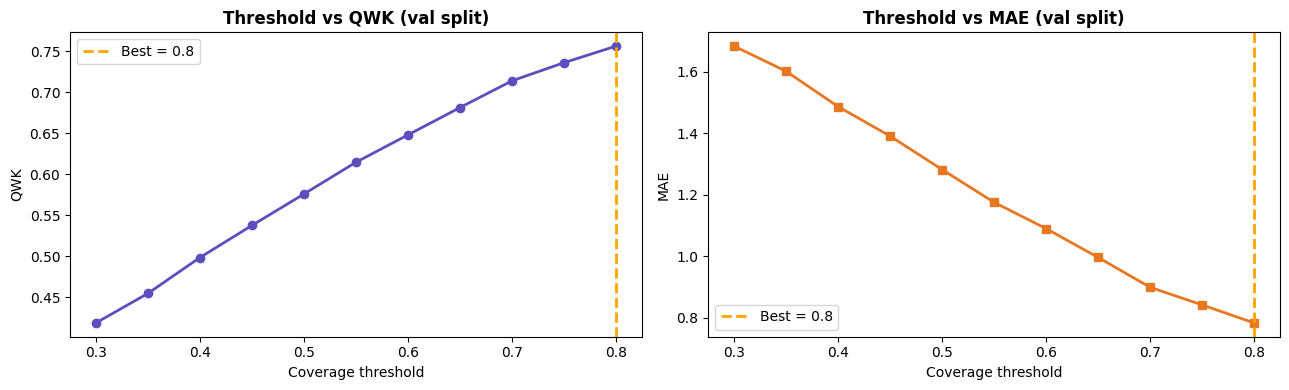

In [17]:
# Plot threshold vs QWK
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(th_df["threshold"], th_df["qwk"], marker="o", color="#5B4FBE", lw=2)
axes[0].axvline(BEST_THRESHOLD, color="orange", lw=2, ls="--",
                label=f"Best = {BEST_THRESHOLD}")
axes[0].set_xlabel("Coverage threshold"); axes[0].set_ylabel("QWK")
axes[0].set_title("Threshold vs QWK (val split)", fontweight="bold"); axes[0].legend()

axes[1].plot(th_df["threshold"], th_df["mae"], marker="s", color="#E87722", lw=2)
axes[1].axvline(BEST_THRESHOLD, color="orange", lw=2, ls="--",
                label=f"Best = {BEST_THRESHOLD}")
axes[1].set_xlabel("Coverage threshold"); axes[1].set_ylabel("MAE")
axes[1].set_title("Threshold vs MAE (val split)", fontweight="bold"); axes[1].legend()

plt.tight_layout(); plt.show()

---
## Step 6 · CSRF MLP — Confidence Calibration  ★

In [18]:
FEATURE_NAMES = ["coverage","similarity","marks_awarded","crit_idx_norm",
                 "n_criteria_norm","pred_score_norm","student_len_norm","model_len_norm"]

def extract_features(dr: DecomposedRubric,
                     student_text: str, model_answer: str) -> np.ndarray:
    n = len(dr.criteria)
    return np.array([[c.coverage, c.match_similarity,
                      c.marks_awarded/max(dr.total_marks,1),
                      i/max(n-1,1), min(n/10,1.0),
                      dr.predicted_score/max(dr.total_marks,1),
                      min(len(student_text)/500,1.0),
                      min(len(model_answer)/500,1.0)]
                     for i, c in enumerate(dr.criteria)], dtype=np.float32)

class CSRFCalibrator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(8, 128), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128, 64), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, 1), nn.Sigmoid())
    def forward(self, x): return self.net(x).squeeze(-1)

csrf_mlp = CSRFCalibrator().to(DEVICE)
print(f"CSRF MLP  |  params: {sum(p.numel() for p in csrf_mlp.parameters()):,}")

CSRF MLP  |  params: 9,473


In [19]:
# Build CSRF dataset from TRAIN split using tuned threshold
print(f"Building CSRF training data (threshold={BEST_THRESHOLD}) …")
X_tr, y_tr = [], []
for i, entry in enumerate(rubric_train):
    dr    = decompose_rubric(entry, entry.student_answer, threshold=BEST_THRESHOLD)
    feats = extract_features(dr, entry.student_answer, entry.model_answer)
    lbl   = float(np.clip(
        1.0 - abs(dr.predicted_score - entry.teacher_marks) / max(entry.total_marks,1), 0, 1))
    for f in feats: X_tr.append(f); y_tr.append(lbl)
    if (i+1) % 1000 == 0: print(f"  {i+1}/{len(rubric_train)}")
X_tr = np.array(X_tr, dtype=np.float32)
y_tr = np.array(y_tr, dtype=np.float32)
print(f"CSRF samples: {len(X_tr)}  |  mean label: {y_tr.mean():.3f}")

Building CSRF training data (threshold=0.8) …
  1000/3419
  2000/3419
  3000/3419
CSRF samples: 3439  |  mean label: 0.918


In [20]:
class CSRFDS(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

opt2 = torch.optim.Adam(csrf_mlp.parameters(), lr=1e-3)
sch2 = torch.optim.lr_scheduler.CosineAnnealingLR(opt2, T_max=25)
dl2  = DataLoader(CSRFDS(X_tr, y_tr), batch_size=256, shuffle=True)
csrf_mlp.train()

for ep in range(25):
    el = 0
    for Xb, yb in dl2:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        loss = F.mse_loss(csrf_mlp(Xb), yb)
        opt2.zero_grad(); loss.backward(); opt2.step(); el += loss.item()
    sch2.step()
    if (ep+1) % 5 == 0: print(f"  CSRF ep{ep+1:02d}  loss={el/len(dl2):.5f}")
csrf_mlp.eval()
print("CSRF MLP training complete")

  CSRF ep05  loss=0.01172
  CSRF ep10  loss=0.00773
  CSRF ep15  loss=0.00634
  CSRF ep20  loss=0.00604
  CSRF ep25  loss=0.00590
CSRF MLP training complete


In [21]:
CONFIDENCE_THRESHOLD = 0.70

def route(entry: RubricEntry, student_text: str,
          threshold: float = CONFIDENCE_THRESHOLD) -> dict:
    dr    = decompose_rubric(entry, student_text, threshold=BEST_THRESHOLD)
    feats = extract_features(dr, student_text, entry.model_answer)
    with torch.no_grad():
        confs = csrf_mlp(torch.tensor(feats, dtype=torch.float32).to(DEVICE)).cpu().numpy()
    overall = float(confs.mean())
    return {"predicted_score": dr.predicted_score, "total_marks": entry.total_marks,
            "criterion_confidences": confs.tolist(), "overall_confidence": round(overall,4),
            "decision": "Auto Grade" if overall >= threshold else "Human Review",
            "decomposed_rubric": dr}

def finalise_grade(entry: RubricEntry, routing: dict, human_mark=None) -> dict:
    if routing["decision"] == "Auto Grade":
        return {**routing, "final_score": round(routing["predicted_score"]),
                "graded_by": "Auto Grade"}
    score = human_mark if human_mark is not None else round(routing["predicted_score"])
    return {**routing, "final_score": int(np.clip(score, 0, entry.total_marks)),
            "graded_by": "Human Review"}

print("route() + finalise_grade()")

route() + finalise_grade()


---
## Step 7 · LLM Feedback Generator — Llama 3.1 (Groq)

In [22]:
def build_feedback_prompt(entry: RubricEntry, student_text: str, grading: dict) -> str:
    dr     = grading["decomposed_rubric"]
    cblock = "\n".join(
        f"  Criterion {i+1}: {c.text}\n"
        f"    Student matched: \"{c.best_match_sent[:80]}\"\n"
        f"    Coverage: {c.coverage:.0%}  Marks: {c.marks_awarded:.1f}"
        for i, c in enumerate(dr.criteria))
    return f"""You are an expert teacher grading a student's exam answer.
Write feedback in exactly FOUR sections:

✅ Strengths
❌ Gaps
💡 Suggestions
🎯 Summary

QUESTION: {entry.question}
MODEL ANSWER: {entry.model_answer}
STUDENT ANSWER: {student_text}
PER-CRITERION BREAKDOWN:
{cblock}
FINAL SCORE: {grading['final_score']} / {entry.total_marks}
GRADED BY: {grading['graded_by']}  CONFIDENCE: {grading['overall_confidence']:.0%}

Write 2-3 sentences per section. Be specific, kind, and actionable. Prose only."""

def generate_feedback(entry: RubricEntry, student_text: str, grading: dict) -> str:
    resp = groq_client.chat.completions.create(
        model=GROQ_MODEL,
        messages=[{"role":"user","content":build_feedback_prompt(entry,student_text,grading)}],
        max_tokens=512, temperature=0.4)
    return resp.choices[0].message.content.strip()

print("generate_feedback")

generate_feedback


---
## Step 8 · Final Grade + Evaluation on Val Split (~850 samples)
###

In [23]:
@dataclass
class FinalGradeRecord:
    question: str; student_text: str
    score: int; total_marks: int; score_pct: float
    confidence: float; confidence_level: str; graded_by: str
    feedback_text: str; criteria_coverage: List[float]
    criteria_marks: List[float]; timestamp: str

def make_record(entry, student_text, grading, feedback) -> FinalGradeRecord:
    dr = grading["decomposed_rubric"]; conf = grading["overall_confidence"]
    return FinalGradeRecord(
        question=entry.question, student_text=student_text,
        score=grading["final_score"], total_marks=entry.total_marks,
        score_pct=round(grading["final_score"]/max(entry.total_marks,1)*100,1),
        confidence=conf, confidence_level="High" if conf>=CONFIDENCE_THRESHOLD else "Low",
        graded_by=grading["graded_by"], feedback_text=feedback,
        criteria_coverage=[round(c.coverage,4) for c in dr.criteria],
        criteria_marks=[c.marks_awarded for c in dr.criteria],
        timestamp=datetime.utcnow().isoformat()+"Z")

print("FinalGradeRecord + make_record()")

FinalGradeRecord + make_record()


In [24]:
# Batch eval on val split (scoring only — feedback generated for first 10 only)
print(f"Evaluating on {len(rubric_val)} val samples …\n")
records: List[FinalGradeRecord] = []

for i, entry in enumerate(rubric_val):
    r_out   = route(entry, entry.student_answer)
    grading = finalise_grade(entry, r_out)

    # Generate LLM feedback only for first 10 (API rate limit friendly)
    if i < 10:
        feedback = generate_feedback(entry, entry.student_answer, grading)
    else:
        feedback = "(feedback generation skipped for batch eval)"

    rec = make_record(entry, entry.student_answer, grading, feedback)
    records.append(rec)

    if (i+1) % 100 == 0 or i < 5:
        icon = "" if rec.graded_by=="Auto Grade" else ""
        print(f"[{i+1:4d}] {icon} score={rec.score}/{rec.total_marks}  "
              f"conf={rec.confidence:.2f}  "
              f"teacher={entry.teacher_marks}")

n_auto  = sum(1 for r in records if r.graded_by=="Auto Grade")
n_human = len(records) - n_auto
print(f"\nDone  |  Auto Grade: {n_auto}  Human Review: {n_human}")

Evaluating on 855 val samples …

[   1]  score=5/5  conf=0.90  teacher=2
[   2]  score=0/5  conf=0.96  teacher=2
[   3]  score=0/5  conf=0.96  teacher=2
[   4]  score=2/5  conf=0.93  teacher=1
[   5]  score=2/5  conf=0.93  teacher=1
[ 100]  score=3/5  conf=0.88  teacher=2
[ 200]  score=5/5  conf=0.90  teacher=5
[ 300]  score=3/5  conf=0.88  teacher=2
[ 400]  score=2/5  conf=0.92  teacher=2
[ 500]  score=5/5  conf=0.93  teacher=5
[ 600]  score=1/5  conf=0.94  teacher=1
[ 700]  score=5/5  conf=0.89  teacher=3
[ 800]  score=5/5  conf=0.90  teacher=5

Done  |  Auto Grade: 855  Human Review: 0


---
## Accuracy Measurement — All Metrics

In [25]:
pred_arr  = np.array([r.score        for r in records], dtype=float)
teach_arr = np.array([e.teacher_marks for e in rubric_val], dtype=float)
total_arr = np.array([r.total_marks   for r in records],  dtype=float)

mae_e2e   = float(np.abs(pred_arr - teach_arr).mean())
rmse_e2e  = float(np.sqrt(((pred_arr - teach_arr)**2).mean()))
corr_e2e  = float(np.corrcoef(pred_arr, teach_arr)[0,1])
exact_e2e = float((pred_arr == teach_arr).mean() * 100)
w1_e2e    = float((np.abs(pred_arr - teach_arr) <= 1).mean() * 100)
nmae_e2e  = float((np.abs(pred_arr - teach_arr) / total_arr).mean() * 100)

max_mark  = int(total_arr.max())
p_int     = np.clip(np.round(pred_arr).astype(int), 0, max_mark)
t_int     = np.clip(teach_arr.astype(int), 0, max_mark)
qwk_e2e   = cohen_kappa_score(t_int, p_int, weights="quadratic")

# CC-BERT metrics (already computed above)
# Decomposer raw metrics
dr_preds = [round(decompose_rubric(e, e.student_answer, BEST_THRESHOLD).predicted_score)
            for e in rubric_val[:200]]   # sample for speed
dr_teach = [e.teacher_marks for e in rubric_val[:200]]
dr_qwk   = cohen_kappa_score(np.clip(dr_teach,0,max_mark),
                              np.clip(dr_preds,0,max_mark), weights="quadratic")
dr_mae   = float(np.abs(np.array(dr_preds,dtype=float)-np.array(dr_teach,dtype=float)).mean())

# CSRF ECE
conf_arr = np.array([r.confidence for r in records])
within1  = np.abs(pred_arr - teach_arr) <= 1
ece = 0.0
for lo, hi in zip(np.linspace(0,1,6)[:-1], np.linspace(0,1,6)[1:]):
    mask = (conf_arr>=lo)&(conf_arr<hi)
    if mask.sum()==0: continue
    ece += mask.sum() * abs(within1[mask].mean() - conf_arr[mask].mean())
ece /= len(conf_arr)

auto_mask  = np.array([r.graded_by=="Auto Grade" for r in records])
auto_prec  = within1[auto_mask].mean()  if auto_mask.sum()>0  else float("nan")
human_prec = within1[~auto_mask].mean() if (~auto_mask).sum()>0 else float("nan")

print("=" * 52)
print("  FINAL METRICS  (val split, n=" + str(len(records)) + ")")
print("=" * 52)
print(f"  OCR CER              : {mean_cer:.4f}   [< 0.10]")
print(f"  OCR WER              : {mean_wer:.4f}   [< 0.20]")
print(f"  CC-BERT Pearson r    : {ccbert_corr:.4f}   [> 0.60]")
print(f"  CC-BERT MAE          : {ccbert_mae:.4f}   [< 0.15]")
print(f"  Decomposer MAE       : {dr_mae:.4f}   [< 1.00]")
print(f"  Decomposer QWK       : {dr_qwk:.4f}   [> 0.60]")
print(f"  CSRF ECE             : {ece:.4f}   [< 0.10]")
print(f"  Auto Prec ±1         : {auto_prec:.4f}   [> 0.80]")
print(f"  E2E MAE              : {mae_e2e:.4f}   [< 1.00]")
print(f"  E2E RMSE             : {rmse_e2e:.4f}   [< 1.50]")
print(f"  E2E Pearson r        : {corr_e2e:.4f}   [> 0.70]")
print(f"  E2E Exact match      : {exact_e2e:.1f}%   [> 40%]")
print(f"  E2E Within ±1        : {w1_e2e:.1f}%   [> 80%]")
print(f"  E2E QWK ★            : {qwk_e2e:.4f}   [> 0.60]")
print(f"  Best threshold       : {BEST_THRESHOLD}")
print(f"  Auto Grade           : {100*n_auto/len(records):.1f}%")
print("=" * 52)

  FINAL METRICS  (val split, n=855)
  OCR CER              : 0.0667   [< 0.10]
  OCR WER              : 0.1708   [< 0.20]
  CC-BERT Pearson r    : 0.8085   [> 0.60]
  CC-BERT MAE          : 0.1357   [< 0.15]
  Decomposer MAE       : 0.7650   [< 1.00]
  Decomposer QWK       : 0.7918   [> 0.60]
  CSRF ECE             : 0.0622   [< 0.10]
  Auto Prec ±1         : 0.8503   [> 0.80]
  E2E MAE              : 0.7836   [< 1.00]
  E2E RMSE             : 1.2053   [< 1.50]
  E2E Pearson r        : 0.7870   [> 0.70]
  E2E Exact match      : 44.7%   [> 40%]
  E2E Within ±1        : 85.0%   [> 80%]
  E2E QWK ★            : 0.7561   [> 0.60]
  Best threshold       : 0.8
  Auto Grade           : 100.0%


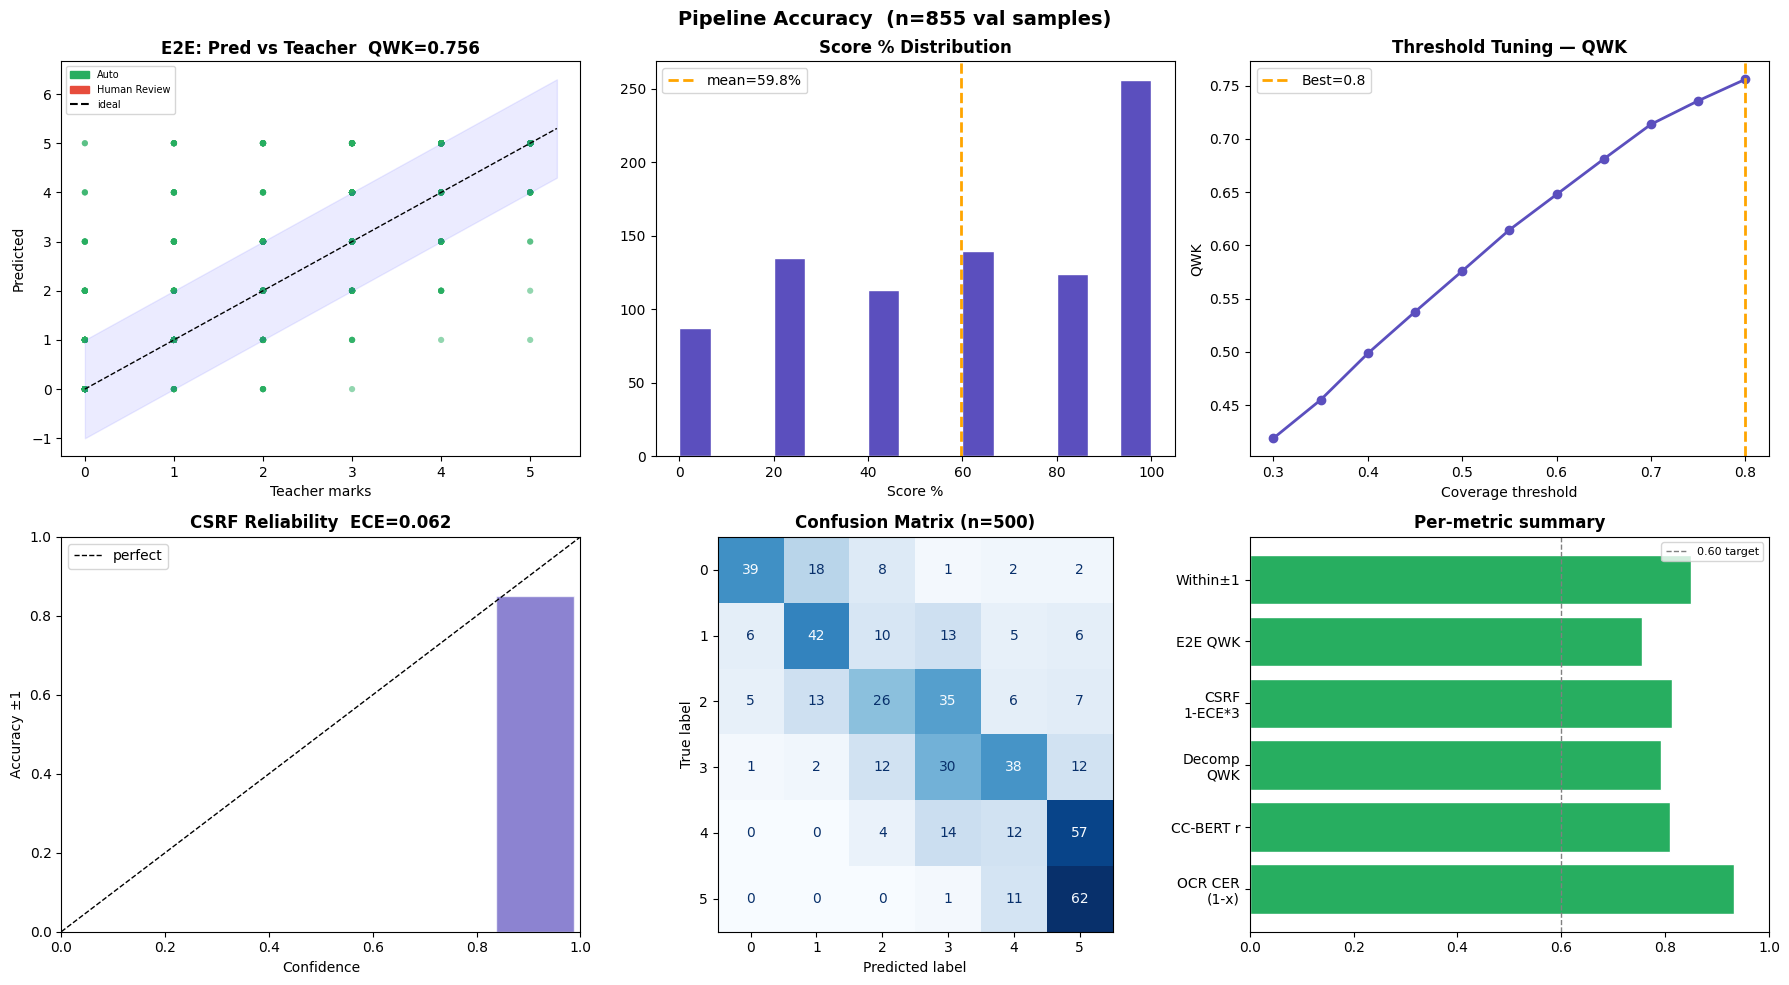

In [26]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(f"Pipeline Accuracy  (n={len(records)} val samples)", fontsize=14, fontweight="bold")

# 1. E2E scatter
colours = ["#27ae60" if r.graded_by=="Auto Grade" else "#e74c3c" for r in records]
axes[0,0].scatter(teach_arr, pred_arr, c=colours, s=20, alpha=0.5, edgecolors="none")
lim = [0, max_mark + 0.3]
axes[0,0].plot(lim,lim,"k--",lw=1,label="ideal")
axes[0,0].fill_between(lim,[l-1 for l in lim],[l+1 for l in lim],
                         alpha=0.08, color="blue", label="±1 band")
axes[0,0].set_title(f"E2E: Pred vs Teacher  QWK={qwk_e2e:.3f}", fontweight="bold")
axes[0,0].set_xlabel("Teacher marks"); axes[0,0].set_ylabel("Predicted")
from matplotlib.patches import Patch
axes[0,0].legend(handles=[Patch(color="#27ae60",label="Auto"),
                            Patch(color="#e74c3c",label="Human Review"),
                            plt.Line2D([0],[0],color="k",ls="--",label="ideal")],
                  fontsize=7)

# 2. Score % distribution
pcts = [r.score_pct for r in records]
axes[0,1].hist(pcts, bins=15, color="#5B4FBE", edgecolor="white")
axes[0,1].axvline(np.mean(pcts), color="orange", lw=2, ls="--",
                   label=f"mean={np.mean(pcts):.1f}%")
axes[0,1].set_title("Score % Distribution", fontweight="bold")
axes[0,1].set_xlabel("Score %"); axes[0,1].legend()

# 3. Threshold tuning curve
axes[0,2].plot(th_df["threshold"], th_df["qwk"], marker="o", color="#5B4FBE", lw=2)
axes[0,2].axvline(BEST_THRESHOLD, color="orange", lw=2, ls="--",
                   label=f"Best={BEST_THRESHOLD}")
axes[0,2].set_title("Threshold Tuning — QWK", fontweight="bold")
axes[0,2].set_xlabel("Coverage threshold"); axes[0,2].set_ylabel("QWK")
axes[0,2].legend()

# 4. Reliability diagram (ECE)
axes[1,0].plot([0,1],[0,1],"k--",lw=1,label="perfect")
bins = np.linspace(0,1,6)
ba, bc = [], []
for lo,hi in zip(bins[:-1],bins[1:]):
    mask=(conf_arr>=lo)&(conf_arr<hi)
    if mask.sum()==0: continue
    ba.append(within1[mask].mean()); bc.append(conf_arr[mask].mean())
axes[1,0].bar(bc, ba, width=0.15, alpha=0.7, color="#5B4FBE", edgecolor="white")
axes[1,0].set_title(f"CSRF Reliability  ECE={ece:.3f}", fontweight="bold")
axes[1,0].set_xlabel("Confidence"); axes[1,0].set_ylabel("Accuracy ±1"); axes[1,0].legend()
axes[1,0].set_xlim(0,1); axes[1,0].set_ylim(0,1)

# 5. Confusion matrix (sample for speed)
N_CM = min(500, len(records))
cm   = confusion_matrix(t_int[:N_CM], p_int[:N_CM],
                         labels=list(range(max_mark+1)))
disp = ConfusionMatrixDisplay(cm, display_labels=list(range(max_mark+1)))
disp.plot(ax=axes[1,1], colorbar=False, cmap="Blues")
axes[1,1].set_title(f"Confusion Matrix (n={N_CM})", fontweight="bold")

# 6. Metrics summary bar
metric_labels = ["OCR CER\n(1-x)", "CC-BERT r", "Decomp\nQWK",
                 "CSRF\n1-ECE*3", "E2E QWK", "Within±1"]
metric_values = [1-mean_cer, max(0,ccbert_corr), max(0,dr_qwk),
                 max(0,1-ece*3), max(0,qwk_e2e), w1_e2e/100]
colours6      = ["#27ae60" if v>=0.60 else "#E87722" if v>=0.40 else "#e74c3c"
                  for v in metric_values]
axes[1,2].barh(metric_labels, metric_values, color=colours6, edgecolor="white")
axes[1,2].axvline(0.60, color="gray", lw=1, ls="--", label="0.60 target")
axes[1,2].set_xlim(0,1); axes[1,2].set_title("Per-metric summary", fontweight="bold")
axes[1,2].legend(fontsize=8)

plt.tight_layout(); plt.show()

In [27]:
summary = pd.DataFrame([
    {"Stage":"OCR Module",          "Metric":"CER",          "Value":f"{mean_cer:.4f}",   "Target":"< 0.10"},
    {"Stage":"OCR Module",          "Metric":"WER",          "Value":f"{mean_wer:.4f}",   "Target":"< 0.20"},
    {"Stage":"CC-BERT",             "Metric":"Pearson r",    "Value":f"{ccbert_corr:.4f}","Target":"> 0.60"},
    {"Stage":"CC-BERT",             "Metric":"MAE",          "Value":f"{ccbert_mae:.4f}", "Target":"< 0.15"},
    {"Stage":"Rubric Decomposer",   "Metric":"MAE",          "Value":f"{dr_mae:.4f}",     "Target":"< 1.00"},
    {"Stage":"Rubric Decomposer",   "Metric":"QWK",          "Value":f"{dr_qwk:.4f}",     "Target":"> 0.60"},
    {"Stage":"CSRF Calibration",    "Metric":"ECE",          "Value":f"{ece:.4f}",        "Target":"< 0.10"},
    {"Stage":"CSRF Calibration",    "Metric":"Auto Prec ±1", "Value":f"{auto_prec:.4f}",  "Target":"> 0.80"},
    {"Stage":"End-to-End",          "Metric":"MAE",          "Value":f"{mae_e2e:.4f}",    "Target":"< 1.00"},
    {"Stage":"End-to-End",          "Metric":"RMSE",         "Value":f"{rmse_e2e:.4f}",   "Target":"< 1.50"},
    {"Stage":"End-to-End",          "Metric":"Pearson r",    "Value":f"{corr_e2e:.4f}",   "Target":"> 0.70"},
    {"Stage":"End-to-End",          "Metric":"Exact match",  "Value":f"{exact_e2e:.1f}%", "Target":"> 40%"},
    {"Stage":"End-to-End",          "Metric":"Within ±1",    "Value":f"{w1_e2e:.1f}%",    "Target":"> 80%"},
    {"Stage":"End-to-End",          "Metric":"QWK ★",        "Value":f"{qwk_e2e:.4f}",    "Target":"> 0.60"},
])
def status(row):
    try:
        v = float(row["Value"].rstrip("%"))
        t = float(row["Target"].lstrip("><").rstrip("%"))
        return "" if (v>=t if ">" in row["Target"] else v<=t) else ""
    except: return "—"
summary["Status"] = summary.apply(status, axis=1)
display(summary)

,Stage,Metric,Value,Target,Status
0,OCR Module,CER,0.0667,< 0.10,
1,OCR Module,WER,0.1708,< 0.20,
2,CC-BERT,Pearson r,0.8085,> 0.60,
3,CC-BERT,MAE,0.1357,< 0.15,
4,Rubric Decomposer,MAE,0.7650,< 1.00,
5,Rubric Decomposer,QWK,0.7918,> 0.60,
6,CSRF Calibration,ECE,0.0622,< 0.10,
7,CSRF Calibration,Auto Prec ±1,0.8503,> 0.80,
8,End-to-End,MAE,0.7836,< 1.00,
9,End-to-End,RMSE,1.2053,< 1.50,


In [28]:
def record_to_dict(r: FinalGradeRecord) -> dict:
    d = asdict(r)
    d["criteria_coverage"] = [float(x) for x in d["criteria_coverage"]]
    d["criteria_marks"]    = [float(x) for x in d["criteria_marks"]]
    return d

output = {"generated_at": datetime.utcnow().isoformat()+"Z",
           "model_info":  {"ocr":"trocr-base-handwritten (independent module)",
                           "embedder":"CC-BERT 10ep cosine-annealing",
                           "threshold":BEST_THRESHOLD,
                           "calibrator":"CSRF MLP 8→128→64→1",
                           "feedback": GROQ_MODEL+" via Groq"},
           "metrics":     {"n_val_samples":len(records),"qwk":round(qwk_e2e,4),
                           "mae":round(mae_e2e,4),"within_1_pct":round(w1_e2e,2),
                           "best_threshold":BEST_THRESHOLD},
           "records":     [record_to_dict(r) for r in records]}

with open("final_grades.json","w") as f: json.dump(output, f, indent=2)

pd.DataFrame([{"question":r.question,"student_text":r.student_text[:100],
               "score":r.score,"total_marks":r.total_marks,"score_pct":r.score_pct,
               "confidence":r.confidence,"confidence_level":r.confidence_level,
               "graded_by":r.graded_by,"timestamp":r.timestamp}
              for r in records]).to_csv("final_grades.csv", index=False)

print("Saved final_grades.json  +  final_grades.csv")
print(f"   QWK={qwk_e2e:.4f}  MAE={mae_e2e:.4f}  Within±1={w1_e2e:.1f}%  n={len(records)}")

Saved final_grades.json  +  final_grades.csv
   QWK=0.7561  MAE=0.7836  Within±1=85.0%  n=855
